###Visualização de dados com Matplotlib

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

####Gráfico de linhas

In [2]:
np.random.seed(7)

#vetor com números inteiros aleatórios entre 1 e 1500 com 10 amostras
y = np.random.randint(low=1, high=1500, size=10)

In [3]:
y

array([ 176, 1221,  538,  503,  212,  920, 1373, 1210, 1423,  536])

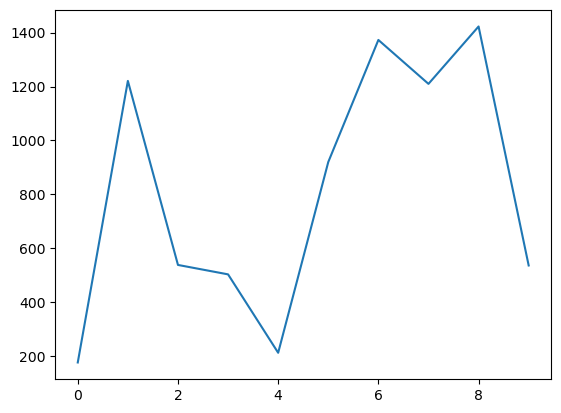

In [4]:
plt.plot(y)

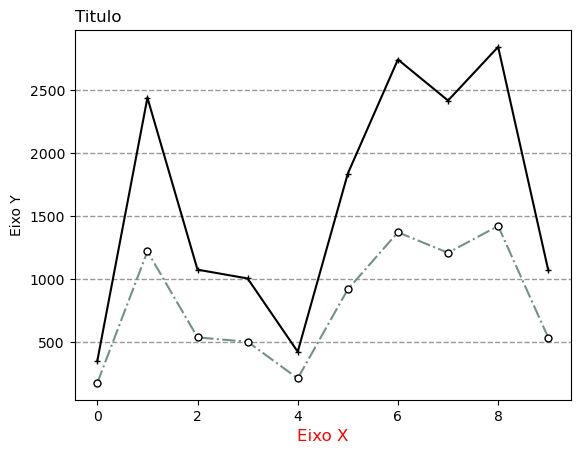

In [ ]:
#Insere a primeira linha no plot
plt.plot(y, color='#749187', marker='o', ms=5, mec='k', markerfacecolor='w', ls='-.')
#marker -> marcador dos pontos; ms -> tamanho do marcador; mec -> cor da linha do marcador; markerfacecolor -> cor da face do marcador; ls -> estilo da linha

#Insere a segunda linha no plot
plt.plot(y*2, marker='+', color='k', ms=5)

#Rótulos
plt.xlabel('Eixo X', color='red', size=12)
plt.ylabel('Eixo Y')
plt.title('Titulo', loc='left') #loc -> localização do título

#Gridlines
plt.grid(axis='y',color='gray', linestyle='--', linewidth=1, alpha=0.8) #alpha -> opacidade da linha
plt.show()

####Subplots

'b' as blue

'g' as green

'r' as red

'c' as cyan

'm' as magenta

'y' as yellow

'k' as black

'w' as white

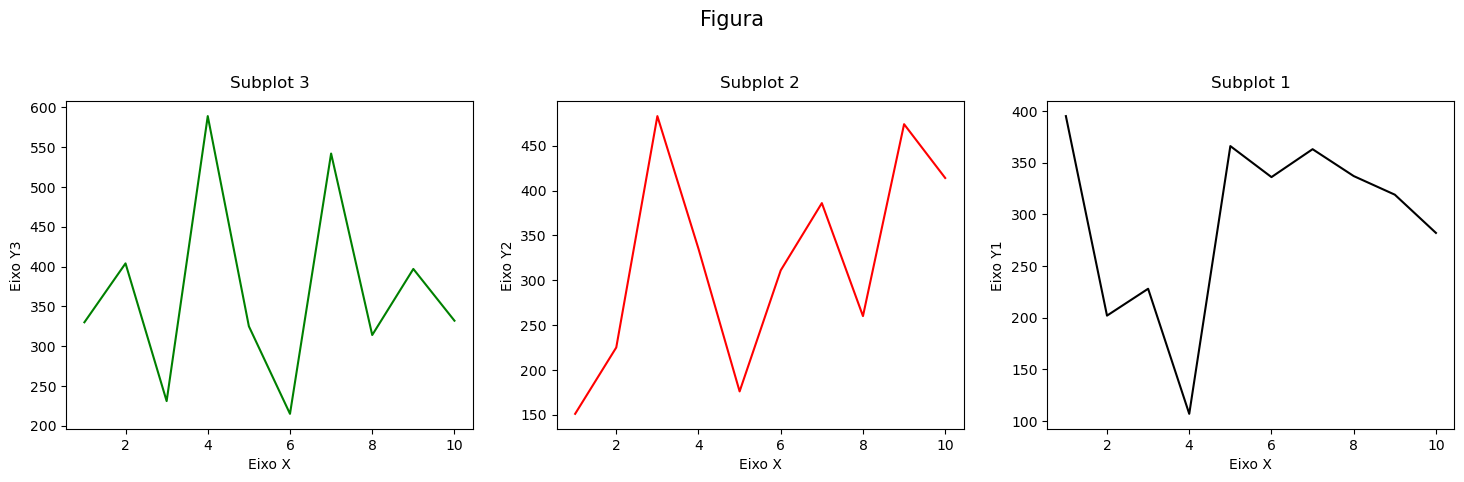

In [13]:
np.random.seed(6)
x = np.arange(1,11)
y1 = np.random.randint(1,400,10)
y2 = np.random.randint(150,500,10)
y3 = np.random.randint(200,600,10)
plt.figure(figsize=(15,5))
plt.suptitle('Figura', fontsize=15)

plt.subplot(1,3,3) #1 linha e 3 colunas e a ordem 
plt.plot(x, y1, color='k')
plt.title('Subplot 1', pad=10)
plt.xlabel('Eixo X')
plt.ylabel('Eixo Y1')

plt.subplot(1,3,2)
plt.plot(x, y2, color='r')
plt.title('Subplot 2', pad=10)
plt.xlabel('Eixo X')
plt.ylabel('Eixo Y2')

plt.subplot(1,3,1)
plt.plot(x, y3, color='g')
plt.title('Subplot 3', pad=10)
plt.xlabel('Eixo X')
plt.ylabel('Eixo Y3')

plt.tight_layout(pad=2)
plt.show()

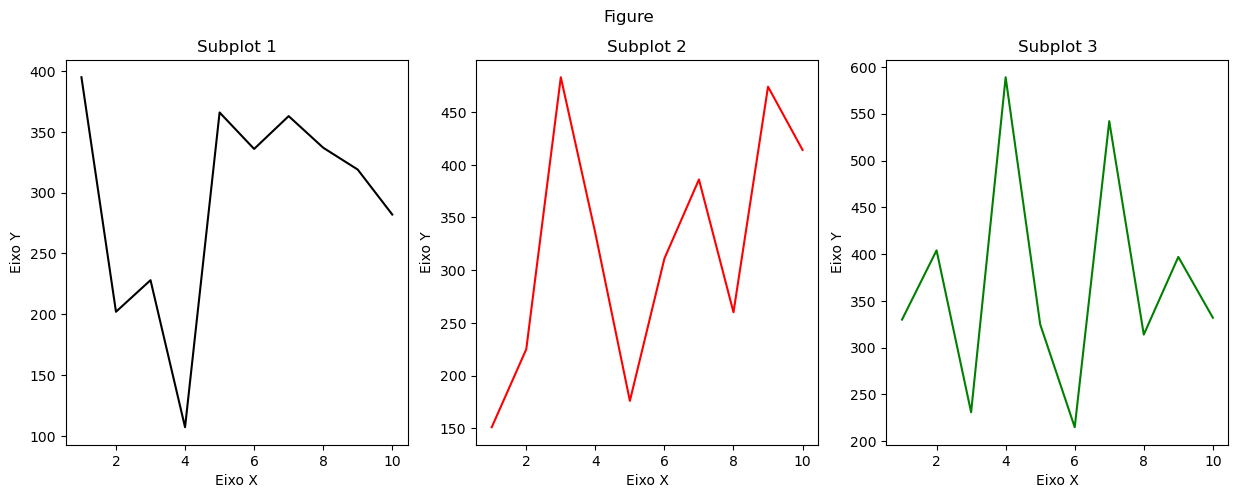

In [14]:
fig, ax = plt.subplots(1,3,figsize=(15,5))
fig.suptitle('Figure')
ax[0].plot(x, y1, color='black')
ax[1].plot(x, y2, color='red')
ax[2].plot(x, y3, color='green')

for i in range(3):
    ax[i].set(title=f'Subplot {i+1}', xlabel = 'Eixo X', ylabel='Eixo Y')

####Histograma e boxplot

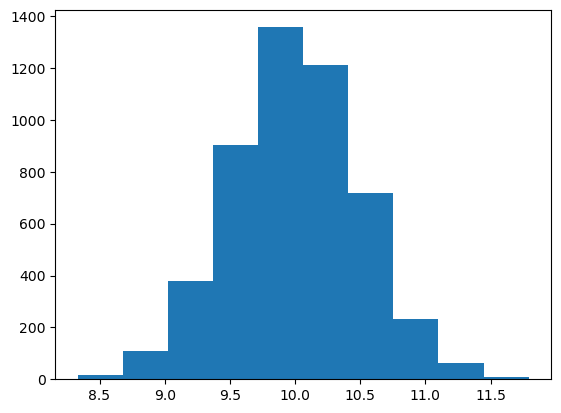

In [15]:
data = np.random.normal(10, 0.5, 5000)
plt.hist(data)
plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x745afdc85590>,
 'caps': [<matplotlib.lines.Line2D at 0x745afdc85810>,
 'boxes': [<matplotlib.lines.Line2D at 0x745afdc85450>],
 'medians': [<matplotlib.lines.Line2D at 0x745afdc85a90>],
 'fliers': [<matplotlib.lines.Line2D at 0x745afdc85bd0>],
 'means': []}

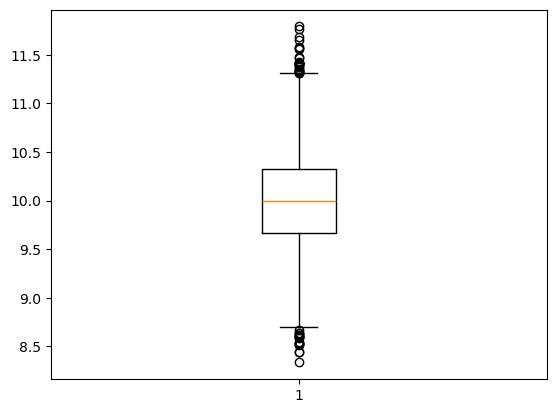

In [16]:
plt.boxplot(data)

####Scatter plot

In [17]:
x = np.random.normal(10, 0.5, 100)
y = np.random.uniform(0, 20, 100)

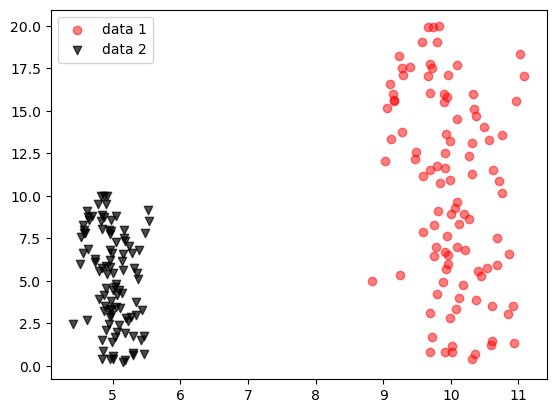

In [18]:
fig = plt.figure()
ax = plt.axes()
ax.scatter(x, y, marker='o', color='red', label='data 1', alpha=0.5)
ax.scatter(x*0.5, y*0.5, marker='v', color='black', label='data 2', alpha=0.7)
ax.legend()

####Dados econômicos

In [19]:
import plotly.express as px

In [21]:
px.data.gapminder()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
...,...,...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306,ZWE,716
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786,ZWE,716
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960,ZWE,716
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623,ZWE,716


In [23]:
df = px.data.gapminder().query('country == "Brazil"').set_index('year')
df.head()

,country,continent,lifeExp,pop,gdpPercap,iso_alpha,iso_num
year,,,,,,,
1952,Brazil,Americas,50.917,56602560,2108.944355,BRA,76
1957,Brazil,Americas,53.285,65551171,2487.365989,BRA,76
1962,Brazil,Americas,55.665,76039390,3336.585802,BRA,76
1967,Brazil,Americas,57.632,88049823,3429.864357,BRA,76
1972,Brazil,Americas,59.504,100840058,4985.711467,BRA,76


Text(0.5, 0, 'Tempo')

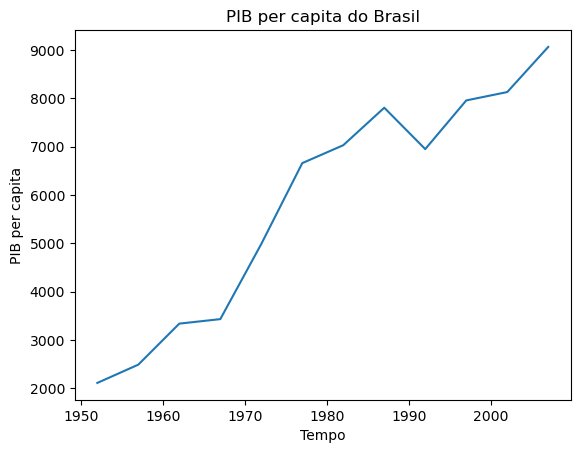

In [25]:
plt.plot(df.index, df['gdpPercap'])
plt.title('PIB per capita do Brasil')
plt.ylabel('PIB per capita')
plt.xlabel('Tempo')

/tmp/ipykernel_15399/1611833776.py:4: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



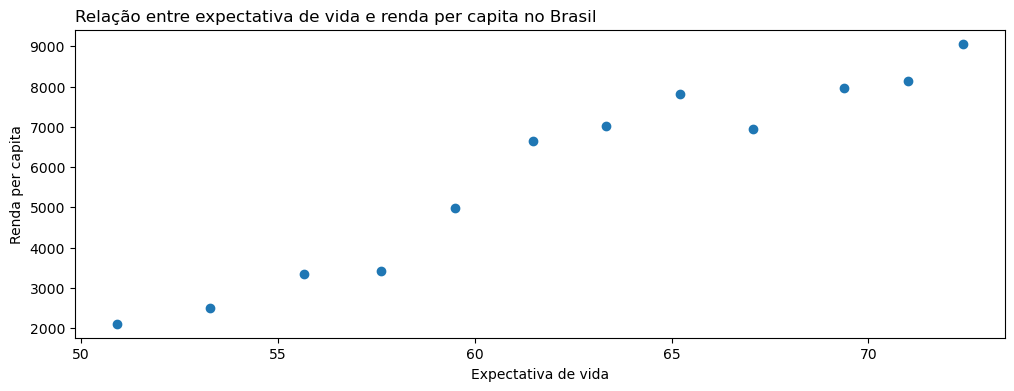

In [27]:
title = 'Relação entre expectativa de vida e renda per capita no Brasil'

plt.figure(figsize=(12,4))
plt.scatter(df['lifeExp'], df['gdpPercap'], cmap='viridis')
plt.xlabel('Expectativa de vida')
plt.ylabel('Renda per capita')
plt.title(title, loc='left')
plt.show()

Text(0.5, 1.0, 'População brasileira')

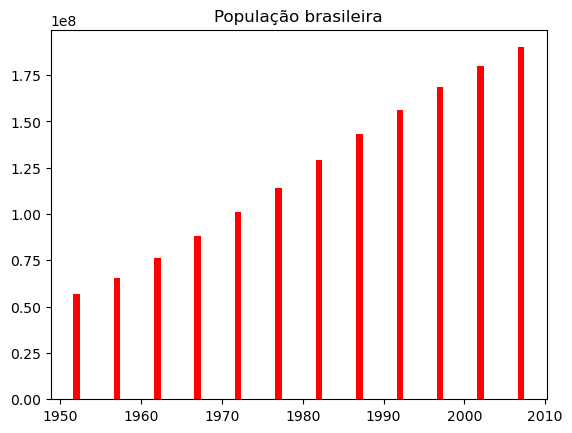

In [28]:
plt.bar(x=df.index, height=df['pop'], color='red')
plt.title('População brasileira')

In [29]:
def filtrar_continentes(continente):
    df = px.data.gapminder()
    df = df[df['continent'] == continente]
    return df


def filtrar_pais(pais, variavel):
    'Filtra algum país da amostra para as variáveis "pop", "gdpPercap" e "pop"'
    df = px.data.gapminder()
    df = df[df['country'] == pais][variavel]
    return df

/tmp/ipykernel_15399/2081542429.py:4: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Text(0, 0.5, 'Renda per capita')

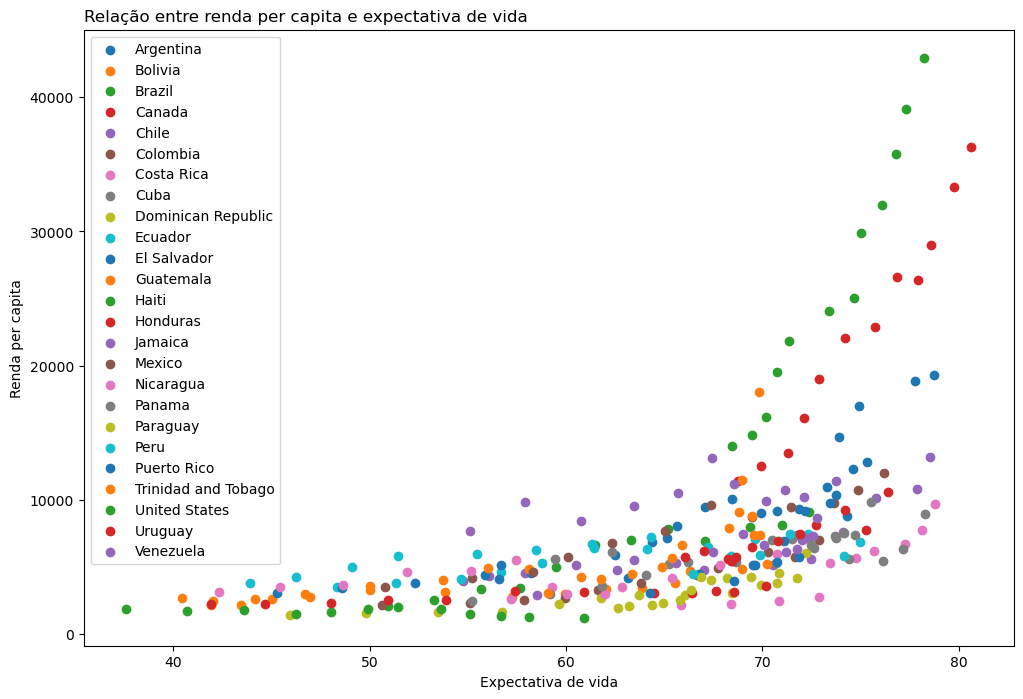

In [33]:
americas = filtrar_continentes('Americas')
paises = americas['country'].unique()
plt.figure(figsize=(12,8))
plt.legend()
for pais in paises:
    plt.scatter(filtrar_pais(pais=pais, variavel = 'lifeExp'), filtrar_pais(pais=pais, variavel = 'gdpPercap'))
    
plt.legend(labels=paises, loc='best')
plt.title('Relação entre renda per capita e expectativa de vida', loc='left')
plt.xlabel('Expectativa de vida')
plt.ylabel('Renda per capita')

####Seaborn 

Seaborn é uma biblioteca de visualização de dados do Python baseado no Matplotlib. Ele provê uma interface de alto nível para construção de gráficos estatísticos atrativos e informativos

In [34]:
import seaborn as sns

In [35]:
#Definir tema
sns.set_theme(style='darkgrid')

In [36]:
#Dados
base_dados = sns.load_dataset('tips')

base_dados.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [50]:
#Renomeando as colunas
base_dados.rename(columns={
    'Total_gosjeta': 'Total_conta',
    'tip': 'Gorjeta',
    'sex': 'Sexo',
    'smoker': 'Fumante',
    'day': 'Dia_semana',
    'time': 'Período',
    'size': 'Pessoas_na_mesa'
}, inplace=True)

In [51]:
base_dados.head()

,Total_conta,Gorjeta,Sexo,Fumante,Dia_semana,Período,Pessoas_na_mesa
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


####Gráfico relplot

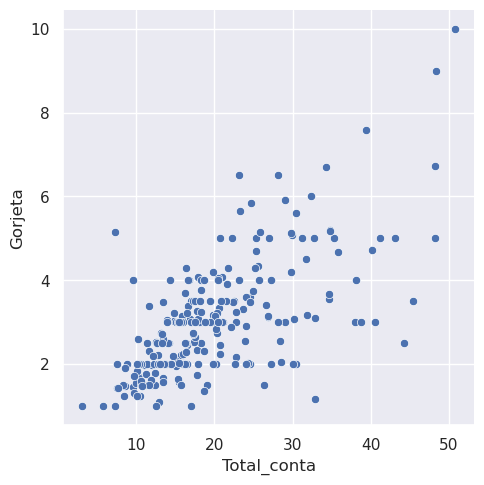

In [45]:
sns.relplot(x='Total_conta', y = 'Gorjeta', data=base_dados)

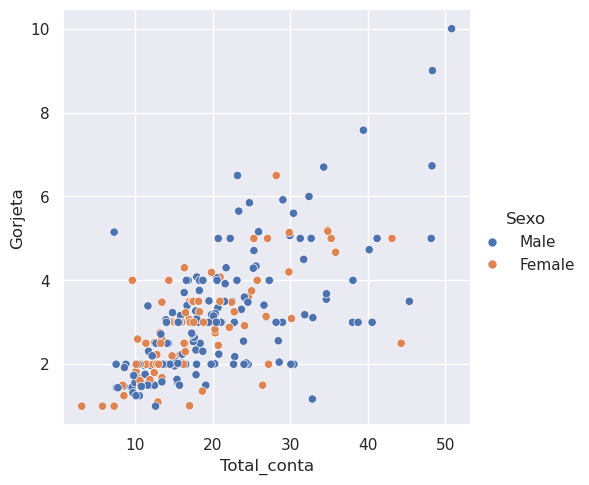

In [46]:
#Passando outro parâmetro como classe no gráfico
sns.relplot(x='Total_conta', y = 'Gorjeta', data=base_dados, hue='Sexo')

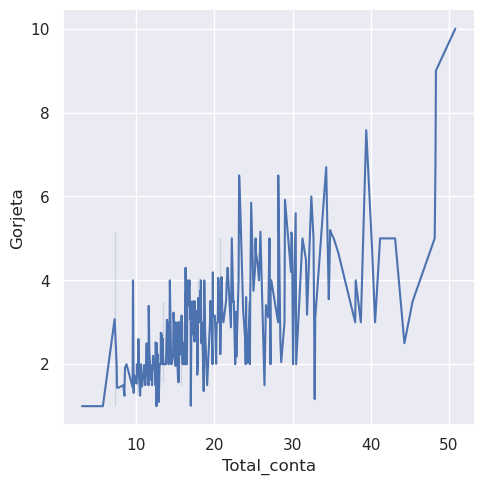

In [47]:
#Gráfico de linha com 2 eixos
sns.relplot(x='Total_conta', y = 'Gorjeta', data=base_dados, kind='line')

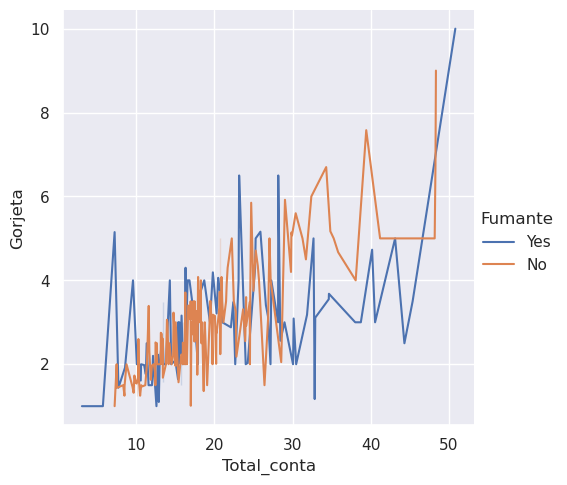

In [52]:
sns.relplot(x='Total_conta', y = 'Gorjeta', data=base_dados, kind='line', hue='Fumante')

####Gráfico histplot

<Axes: xlabel='Total_conta', ylabel='Count'>

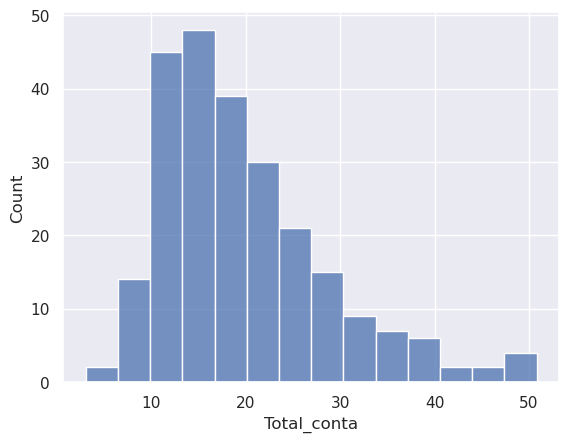

In [54]:
sns.histplot(data=base_dados, x='Total_conta')

<Axes: xlabel='Total_conta', ylabel='Count'>

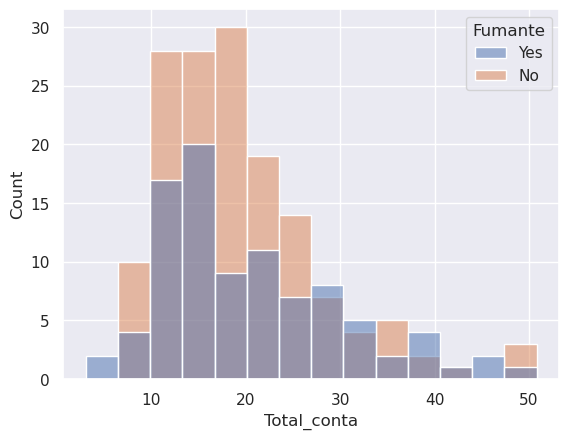

In [55]:
sns.histplot(data=base_dados, x='Total_conta', hue='Fumante')

####GRáfico barplot

<Axes: xlabel='Sexo', ylabel='Total_conta'>

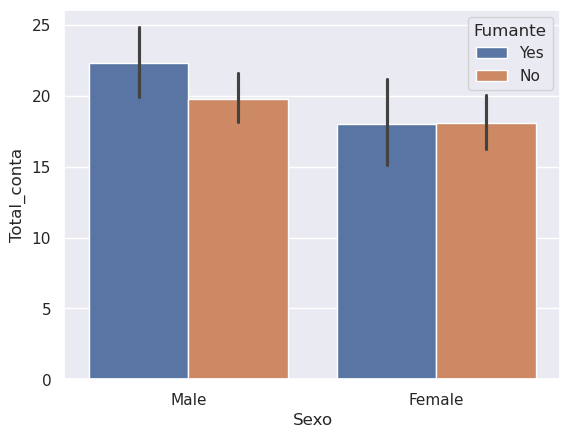

In [56]:
sns.barplot(data=base_dados, x='Sexo', y='Total_conta', hue='Fumante')

####Gráfico pairplot

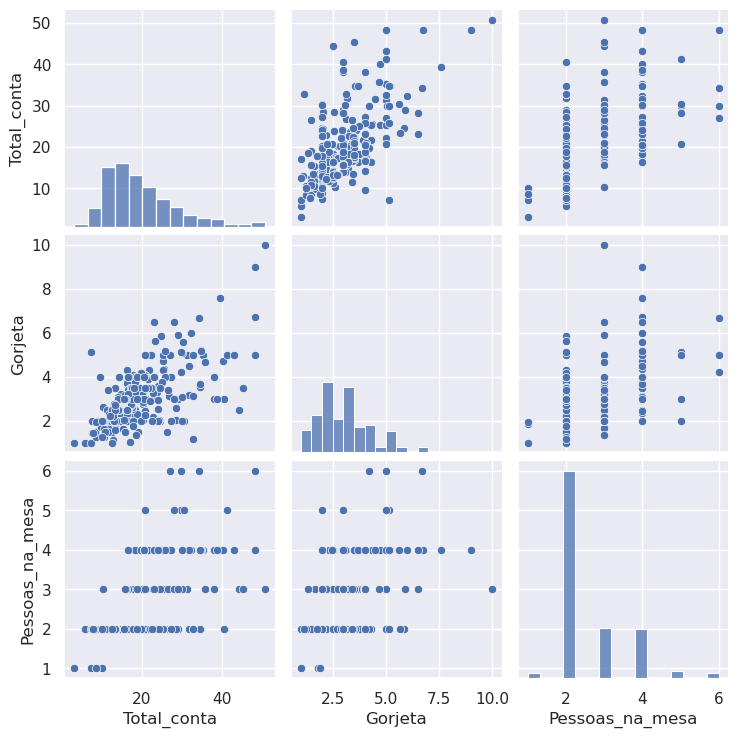

In [57]:
sns.pairplot(base_dados)

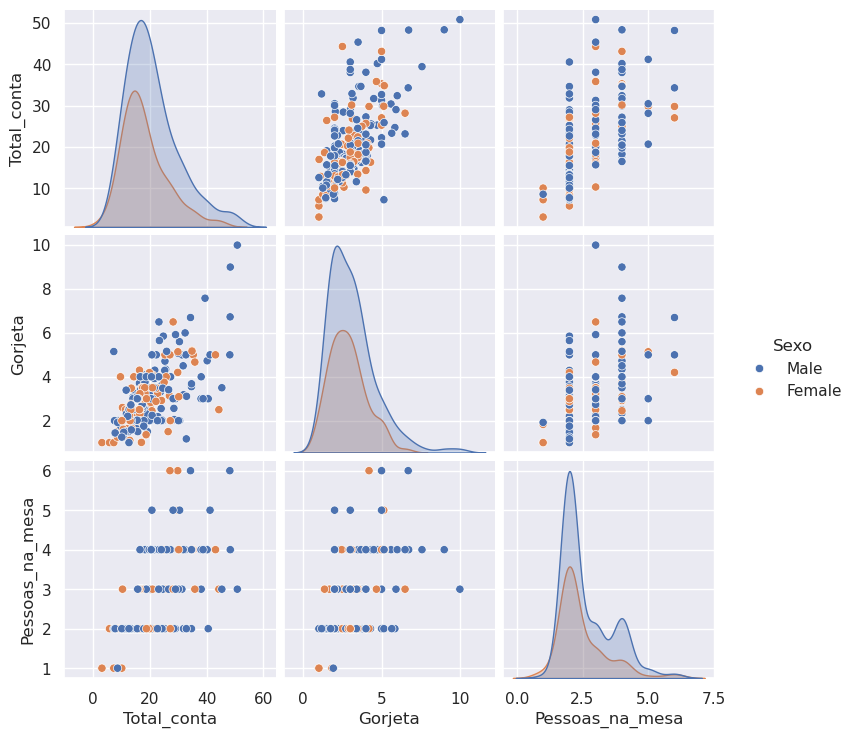

In [58]:
sns.pairplot(base_dados, hue='Sexo')

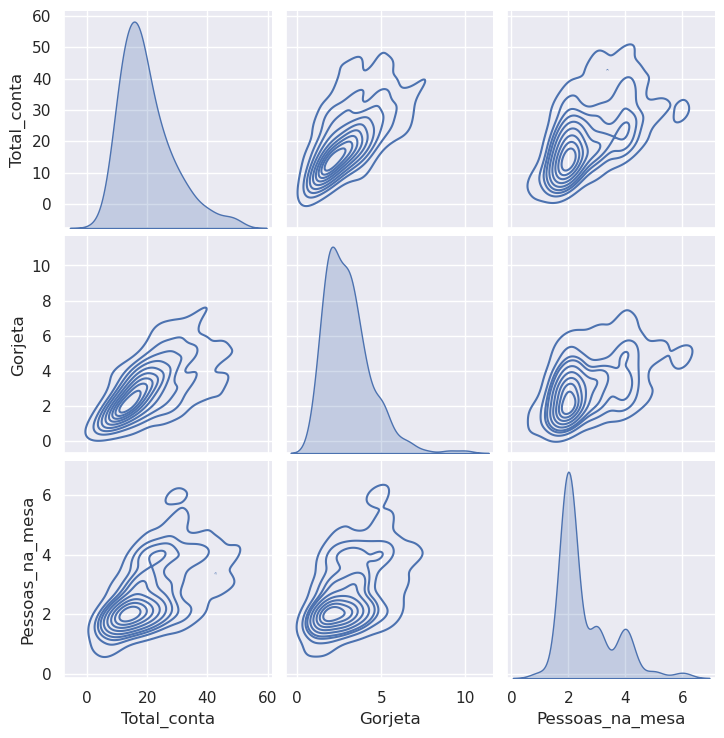

In [59]:
sns.pairplot(base_dados, kind='kde')

####Gráfico boxplot

<Axes: xlabel='Dia_semana', ylabel='Total_conta'>

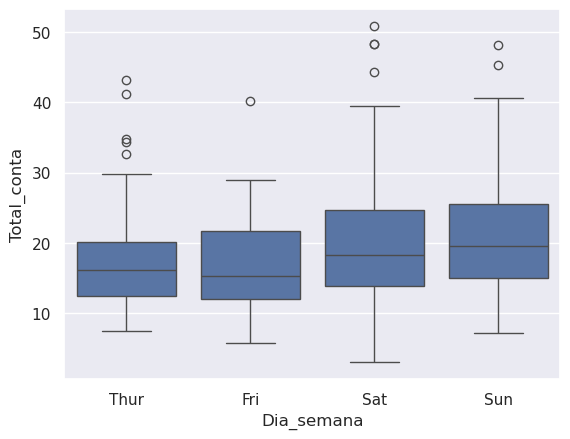

In [60]:
sns.boxplot(data=base_dados, x='Dia_semana', y='Total_conta')

<Axes: xlabel='Dia_semana', ylabel='Total_conta'>

/home/leandro/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.



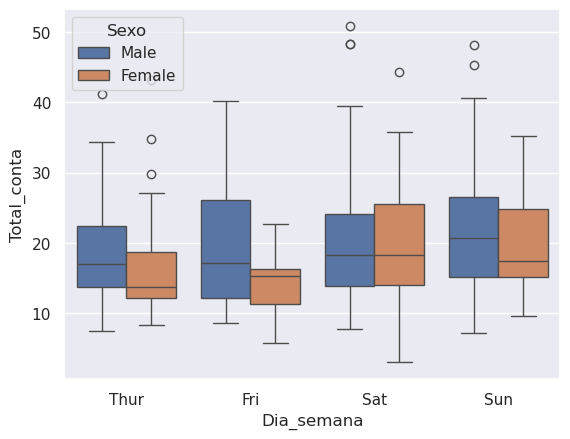

In [61]:
sns.boxplot(data=base_dados, x='Dia_semana', y='Total_conta', hue='Sexo')